# TRM Puzzle Embedding Geometry — SVD / PCA / UMAP

Reuses this project's checkpoint-loading and augmentation-mapping pipeline (config,
env setup, checkpoint fetch, checkpoint-aligned dataset build, `parse_aug_name`) to
pull the checkpoint's own **real, trained** per-augmentation puzzle embeddings for
one or more ARC-AGI-2 tasks, then looks at their geometry:

- **SVD** — how much variance each embedding dimension/component actually carries
  for a single task's ~1000 augmented copies.
- **PCA** — 2D projection, colored by which dihedral transform / color permutation
  produced each row, to look for structure within one task's augmentations.
- **UMAP** — same idea, non-linear, often separates clusters PCA compresses together.

No model inference happens here (no `create_model`/hydra/adam_atan2 needed) --
this only reads the checkpoint's raw `puzzle_emb.weights` tensor and the dataset's
`identifiers.json`, so it's much lighter than the comparison notebook.


## 0. Config

In [1]:
import os

CFG = dict(
    repo_dir       = "/kaggle/working/TinyRecursiveModels",
    dsl_dir        = "/kaggle/working/arc-dsl",
    ckpt_repo_id   = "arcprize/trm_arc_prize_verification",
    ckpt_dest      = "checkpoints/hf_trm",
    num_aug        = 1000,
)
os.makedirs("/kaggle/working", exist_ok=True)


## 1. Environment setup

In [2]:
%%bash
cd /kaggle/working
if [ ! -d TinyRecursiveModels ]; then
    git clone https://github.com/AntonioRoye/TinyRecursiveModels.git
fi
if [ ! -d arc-dsl ]; then
    git clone https://github.com/michaelhodel/arc-dsl.git
fi
cd TinyRecursiveModels

pip install -q --upgrade pip wheel setuptools
# Pinned to a fixed stable release, NOT --pre/nightly -- this is what was silently
# drifting before (nightly grabs whatever build is newest at install time, and
# adam-atan2's compiled extension breaks whenever that changes underneath it).
# Pinning here means every future run installs the exact same torch build, forever,
# until this line is deliberately changed.
pip install -q torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu126
pip install -q -r requirements.txt || echo "[non-fatal] one or more requirements.txt lines failed (expected: adam-atan2) -- continuing"
pip install -q huggingface_hub argdantic pandas matplotlib

echo "--- torch / CUDA diagnostics ---"
python -c "import torch; print('torch', torch.__version__, '| cuda', torch.version.cuda, '| available', torch.cuda.is_available())"
which nvcc && nvcc --version || echo "nvcc not found on PATH"
echo "--- installing adam-atan2 (must succeed) ---"
set -e
pip install --no-cache-dir --no-build-isolation --force-reinstall adam-atan2
python -c "from adam_atan2 import AdamATan2; print('adam_atan2 import OK, backend built successfully')"
set +e
echo "SETUP_CELL_DONE"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 44.3 MB/s eta 0:00:00
--- torch / CUDA diagnostics ---
torch 2.11.0+cu126 | cuda 12.6 | available True
/usr/local/cuda/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
--- installing adam-atan2 (must succeed) ---
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for adam-atan2: filename=adam_atan2-0.0.3-cp312-cp312-linux_x86_64.whl size=207488 sha256=235e81fab721965f5e13327231694fd55f8e20d612ff9ce2277afb4360ac3596
  Stored in directory: /tmp/pip-ephem-wheel-cache-ev7rjh7s/wheels/45/32/31/044d4e2d7dc14d2820c0232d9f41b3ae8cb3d8451451a80dbf
Successfully built adam-atan2
  Attempting uninstall: adam-atan2
    Fou

Cloning into 'TinyRecursiveModels'...
Cloning into 'arc-dsl'...


In [3]:
import sys
sys.path.append(CFG["repo_dir"])
sys.path.append(CFG["dsl_dir"])
os.chdir(CFG["repo_dir"])
print("cwd:", os.getcwd())

import importlib
required = ["torch", "hydra", "omegaconf", "pydantic", "numpy", "pandas",
            "matplotlib", "huggingface_hub", "argdantic",
            "sklearn", "umap",
            "adam_atan2", "adam_atan2_backend"]
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except ImportError as e:
        missing.append((pkg, str(e)))
if missing:
    for pkg, err in missing:
        print(f"MISSING/BROKEN: {pkg} -> {err}")
    raise RuntimeError(
        "One or more core dependencies failed to import -- see package names above. "
        "Paste this exact error to get a targeted fix."
    )
print("All core imports OK.")


cwd: /kaggle/working/TinyRecursiveModels
All core imports OK.


In [4]:
import sys
sys.path.append(CFG["repo_dir"])
sys.path.append(CFG["dsl_dir"])
os.chdir(CFG["repo_dir"])
print("cwd:", os.getcwd())

# Sanity check: catch a missing/broken dependency HERE, not ten cells deep.
# If this fails, the printed package name is what actually needs fixing --
# not necessarily whatever failed egg_info in the setup cell above.
import importlib
required = ["torch", "hydra", "omegaconf", "pydantic", "numpy", "pandas",
            "matplotlib", "huggingface_hub", "argdantic",
            "adam_atan2", "adam_atan2_backend"]  # adam_atan2_backend is the compiled
            # extension that silently failed to build before -- checked explicitly.
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except ImportError as e:
        missing.append((pkg, str(e)))
if missing:
    for pkg, err in missing:
        print(f"MISSING/BROKEN: {pkg} -> {err}")
    raise RuntimeError(
        "One or more core dependencies failed to import -- see package names above. "
        "Paste this exact error to get a targeted fix (likely a pin/version mismatch, "
        "not the same failure as the egg_info warning in the setup cell)."
    )
print("All core imports OK.")

cwd: /kaggle/working/TinyRecursiveModels
All core imports OK.


## 2. Fetch the pretrained checkpoint

In [5]:

import subprocess
subprocess.run(
    ["python", "-m", "experiments.fetch_hf_checkpoints",
     "--repo_id", CFG["ckpt_repo_id"], "--dest", CFG["ckpt_dest"]],
    check=True,
)

import glob
patterns = ["*.pt", "*.pth", "*step_*", "*.bin"]
candidates = []
for pat in patterns:
    candidates.extend(glob.glob(f'{CFG["ckpt_dest"]}/**/{pat}', recursive=True))
candidates = sorted(set(candidates))
assert candidates, f'No checkpoint files found under {CFG["ckpt_dest"]} -- inspect the directory manually.'
print("All candidate checkpoint files found:")
for c in candidates:
    print(" ", c)

v2_candidates = [c for c in candidates if "arc_v2_public" in c]
assert v2_candidates, "No arc_v2_public checkpoint found among candidates -- inspect the printed list above."
V2_CKPT_PATH = sorted(v2_candidates)[-1]
print("\nV2_CKPT_PATH (explicitly selected from candidates, NOT guessed):", V2_CKPT_PATH)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 11 files: 100%|██████████| 11/11 [00:13<00:00,  1.27s/it]


Downloaded to: /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm

Candidate checkpoint files:
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public/step_518071.metadata | sha256=49f2b6612d62bc8af9f0552a809f3e25e04fd6ddec2e012043ad702da7262ec0
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v2_public/step_723914.metadata | sha256=1d55b0d9e34d488485c5ff0b1553ddb913c8f6ba59669682fdc021aa721541ab
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public/step_518071 | sha256=53689643ad1606d7c22c758f8af0a71b3b66275dea074f214d2f1048d9a01fb0
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v2_public/step_723914 | sha256=8d7036b97e7ea38c7dd29d01216bfcfc4e212af3024d5233fe40dd3059e8f4a9

Use one of the above paths as load_checkpoint=... for experiments.run_exp1
All candidate checkpoint files found:
  checkpoints/hf_trm/arc_v1_public/step_518071
  checkpoints/hf_trm/arc_v2_public/ste

## 3. Task loading + augmentation-name parsing utilities

Same as the comparison notebook -- needed here so a raw embedding row can be
traced back to which task, which dihedral transform, and which color permutation
produced it.

In [6]:

import json as _json
import copy
import random
import numpy as np
import torch
from pathlib import Path

with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_training2_challenges.json') as f:
    _full_challenges_v2 = _json.load(f)
with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_training2_solutions.json') as f:
    _full_solutions_v2 = _json.load(f)

tasks_v2 = copy.deepcopy(_full_challenges_v2)
for tid, sol in _full_solutions_v2.items():
    if tid in tasks_v2:
        for i, out in enumerate(sol):
            if i < len(tasks_v2[tid]["test"]):
                tasks_v2[tid]["test"][i]["output"] = out

all_task_ids_v2 = list(tasks_v2.keys())
print(f"{len(all_task_ids_v2)} ARC-AGI-2 training tasks loaded with ground truth.")

from dataset.build_arc_dataset import PuzzleIdSeparator, arc_grid_to_np
from dataset.common import dihedral_transform


def parse_aug_name(name: str):
    '''Inverse of aug()'s name construction: recovers (trans_id, forward_color_mapping)
    from an augmented identifier string. Returns None for a canonical (un-augmented) name.'''
    if PuzzleIdSeparator not in name:
        return None
    _canonical, trans_part, perm_part = name.split(PuzzleIdSeparator)
    trans_id = int(trans_part[1:])
    mapping = np.array([int(c) for c in perm_part], dtype=np.uint8)
    return trans_id, mapping


1000 ARC-AGI-2 training tasks loaded with ground truth.


## 4. Build the baseline dataset (identifiers only, disk-safe) + load the checkpoint's real embedding table

Only `identifiers.json` matters for this analysis -- `all__inputs.npy`/`all__labels.npy`
are skipped entirely (no inference happens in this notebook), same disk-safe pattern
as the comparison notebook. Building on the **full** task set (not a subset) is what
makes the built dataset's row order match the checkpoint's own training-time order --
confirmed below by checking the identifier count against the checkpoint's embedding
table shape directly, rather than assumed.

In [7]:

import shutil

v2_baseline_data = "data/v2-full-aug-1000"

if not (Path(v2_baseline_data) / "identifiers.json").exists():
    for stale in ["checkpoints/hf_trm/arc_v1_public",
                  "checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public"]:
        p = Path(CFG["repo_dir"]) / stale
        if p.exists():
            shutil.rmtree(p, ignore_errors=True)
            print("Removed", p)

    from dataset.build_arc_dataset import DataProcessConfig, convert_dataset
    import numpy as _np

    _orig_save = _np.save
    def _skip_big_arrays(file, arr, *a, **kw):
        fname = str(file)
        if fname.endswith("__inputs.npy") or fname.endswith("__labels.npy"):
            return
        return _orig_save(file, arr, *a, **kw)

    _np.save = _skip_big_arrays
    try:
        convert_dataset(DataProcessConfig(
            input_file_prefix="kaggle/combined/arc-agi",
            output_dir=v2_baseline_data,
            subsets=["training2", "evaluation2", "concept"],
            test_set_name="evaluation2",
            num_aug=CFG["num_aug"],
            puzzle_identifiers_start=1,
        ))
    finally:
        _np.save = _orig_save
else:
    print(f"{v2_baseline_data} already exists -- skipping rebuild.")

print("identifiers.json present:", (Path(v2_baseline_data) / "identifiers.json").exists())


Removed /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public
Removed /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public
[Puzzle bd14c3bf] augmentation not full, only 574
[Puzzle 8dab14c2] augmentation not full, only 575
[Puzzle 3aa6fb7a] augmentation not full, only 576
[Puzzle e6de6e8f] augmentation not full, only 576
[Puzzle 5c0a986e] augmentation not full, only 576
[Puzzle 2697da3f] augmentation not full, only 72
[Puzzle 3618c87e] augmentation not full, only 576
[Puzzle 5168d44c] augmentation not full, only 576
[Puzzle 9bebae7a] augmentation not full, only 575
[Puzzle 90f3ed37] augmentation not full, only 576
[Puzzle 1990f7a8] augmentation not full, only 72
[Puzzle 20981f0e] augmentation not full, only 576
[Puzzle a934301b] augmentation not full, only 576
[Puzzle 18419cfa] augmentation not full, only 576
[Puzzle cce03e0d] augmentation not full, only 576
[Puzzle 4612dd53] augmentation not full, only 576
[Puzzle d37a1ef5] au

In [8]:

sd_v2 = torch.load(V2_CKPT_PATH, map_location="cpu")
if any(isinstance(k, str) and k.startswith("_orig_mod.") for k in sd_v2.keys()):
    sd_v2 = {(k[10:] if k.startswith("_orig_mod.") else k): v for k, v in sd_v2.items()}
ckpt_puzzle_emb_v2 = sd_v2["model.inner.puzzle_emb.weights"]
print("v2 ckpt puzzle_emb shape:", tuple(ckpt_puzzle_emb_v2.shape))

v2_baseline_ids = _json.loads(Path(v2_baseline_data, "identifiers.json").read_text())
print("identifiers.json row count:", len(v2_baseline_ids))

assert len(v2_baseline_ids) == ckpt_puzzle_emb_v2.shape[0], (
    "MISMATCH -- identifiers.json's row count doesn't match the checkpoint's "
    "puzzle_emb table. That means local row index != checkpoint row index, so "
    "any embedding pulled below by index would be WRONG. Do not continue past "
    "this cell until this assert passes."
)
print("Row-index alignment confirmed: local identifiers.json order == checkpoint's real training order.")

task_to_id_v2_baseline = {name: i for i, name in enumerate(v2_baseline_ids)
                           if PuzzleIdSeparator not in name and name != "<blank>"}
print(f"{len(task_to_id_v2_baseline)} distinct tasks indexed.")


v2 ckpt puzzle_emb shape: (1191730, 512)
identifiers.json row count: 1191730
Row-index alignment confirmed: local identifiers.json order == checkpoint's real training order.
1280 distinct tasks indexed.


## 5. Pull a task's real per-augmentation embeddings

`get_task_augmentation_embeddings(task_id)` returns every row belonging to one
task (its ~1000 augmented copies plus the canonical row), pulled directly by index
from `ckpt_puzzle_emb_v2` -- these are the checkpoint's actual trained vectors,
not anything reconstructed or averaged.

In [9]:

def get_task_augmentation_embeddings(task_id: str, max_rows: int = None):
    '''Returns (embeddings [n_rows, dim] as a numpy array, row names, trans_ids array
    [-1 for the canonical un-augmented row], list of color-permutation tuples
    [None for the canonical row]).'''
    rows = [(i, name) for i, name in enumerate(v2_baseline_ids)
            if name.split(PuzzleIdSeparator)[0] == task_id]
    if not rows:
        raise KeyError(f"'{task_id}' not found in v2_baseline_ids -- check spelling / that it's "
                        f"in the ARC-AGI-2 training subset this notebook loaded.")
    if max_rows is not None:
        rows = rows[:max_rows]

    idxs = [i for i, _ in rows]
    names = [n for _, n in rows]
    emb = ckpt_puzzle_emb_v2[idxs].numpy()

    trans_ids, color_perms = [], []
    for n in names:
        parsed = parse_aug_name(n)
        if parsed is None:
            trans_ids.append(-1)
            color_perms.append(None)
        else:
            t, mapping = parsed
            trans_ids.append(t)
            color_perms.append(tuple(mapping.tolist()))

    return emb, names, np.array(trans_ids), color_perms


TEST_TASK_ID = all_task_ids_v2[10]
_emb, _names, _trans_ids, _color_perms = get_task_augmentation_embeddings(TEST_TASK_ID)
print(f"{TEST_TASK_ID}: {_emb.shape[0]} rows, dim={_emb.shape[1]}")
print("trans_id distribution:", {int(t): int((_trans_ids == t).sum()) for t in sorted(set(_trans_ids.tolist()))})


05269061: 1001 rows, dim=512
trans_id distribution: {-1: 1, 0: 112, 1: 113, 2: 141, 3: 126, 4: 125, 5: 126, 6: 130, 7: 127}


## 6. SVD -- variance explained per embedding dimension

For one task's full set of augmented-copy embeddings: how many components carry
real variance vs. how much is redundant/noise. If most variance sits in a small
number of components, that task's augmentations vary along a low-dimensional
subspace of the embedding space -- worth comparing across tasks.

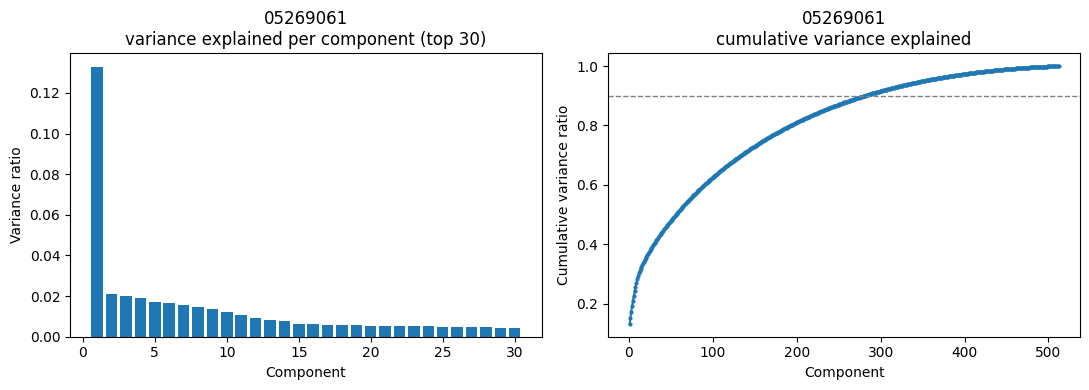

05269061: 282 / 512 components needed to reach 90% variance (embedding dim = 512)


In [10]:

import matplotlib.pyplot as plt

def plot_svd_scree(emb: np.ndarray, title: str = ""):
    centered = emb - emb.mean(axis=0, keepdims=True)
    _U, S, _Vt = np.linalg.svd(centered, full_matrices=False)
    var_ratio = (S ** 2) / np.sum(S ** 2)
    cum_var = np.cumsum(var_ratio)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    n_show = min(30, len(var_ratio))
    axes[0].bar(range(1, n_show + 1), var_ratio[:n_show])
    axes[0].set_title(f"{title}\nvariance explained per component (top {n_show})")
    axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance ratio")

    axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=2)
    axes[1].axhline(0.90, color="gray", linestyle="--", linewidth=1)
    axes[1].set_title(f"{title}\ncumulative variance explained")
    axes[1].set_xlabel("Component"); axes[1].set_ylabel("Cumulative variance ratio")
    plt.tight_layout()
    plt.show()

    n_for_90 = int(np.searchsorted(cum_var, 0.90) + 1)
    print(f"{title}: {n_for_90} / {len(var_ratio)} components needed to reach 90% variance "
          f"(embedding dim = {emb.shape[1]})")
    return S, var_ratio, cum_var


SVD_TASK_ID = all_task_ids_v2[10]
emb, names, trans_ids, color_perms = get_task_augmentation_embeddings(SVD_TASK_ID)
_ = plot_svd_scree(emb, title=SVD_TASK_ID)


## 7. PCA -- look for clusters within one task's augmentations

Colored two ways: by dihedral transform ID (8 discrete values, -1 = canonical row),
and by a hash of the color permutation. If augmentations cluster by transform, the
embedding space has learned to separate rotations/flips geometrically; if not, that
structure isn't visible in PCA's top-2 linear components (try UMAP next).

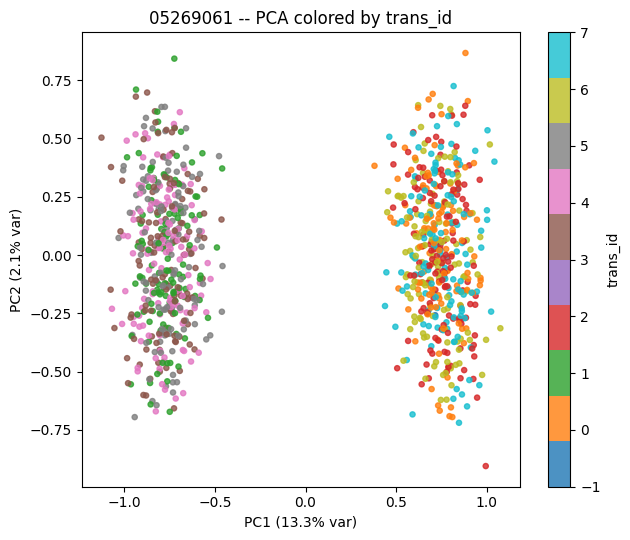

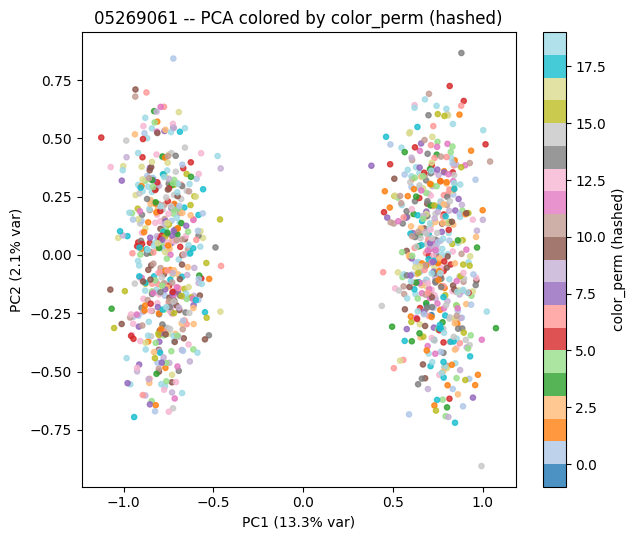

In [11]:

from sklearn.decomposition import PCA

def plot_pca_scatter(emb: np.ndarray, color_values, title: str = "", label: str = "", cmap: str = "tab10"):
    pca = PCA(n_components=2)
    proj = pca.fit_transform(emb)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=color_values, cmap=cmap, s=14, alpha=0.8)
    ax.set_title(f"{title} -- PCA colored by {label}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.colorbar(sc, ax=ax, label=label)
    plt.tight_layout()
    plt.show()
    return proj


color_perm_hash = np.array([hash(cp) % 20 if cp is not None else -1 for cp in color_perms])

_ = plot_pca_scatter(emb, trans_ids, title=SVD_TASK_ID, label="trans_id", cmap="tab10")
_ = plot_pca_scatter(emb, color_perm_hash, title=SVD_TASK_ID, label="color_perm (hashed)", cmap="tab20")


## 8. UMAP -- same colorings, non-linear projection

UMAP can separate clusters that overlap in PCA's linear 2D projection. Same task,
same colorings as Section 7, for direct comparison.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


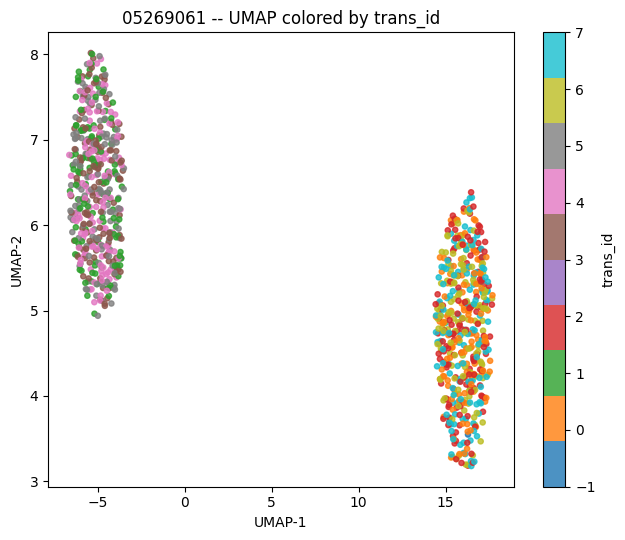

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


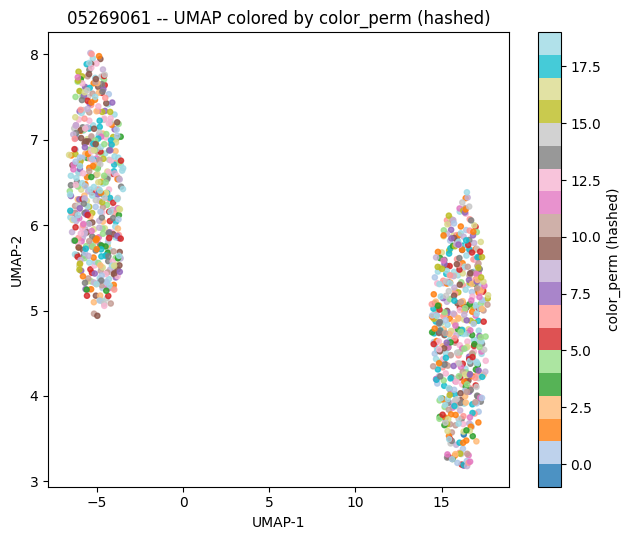

In [12]:

import umap

def plot_umap_scatter(emb: np.ndarray, color_values, title: str = "", label: str = "",
                       cmap: str = "tab10", n_neighbors: int = 15, min_dist: float = 0.1,
                       seed: int = 0):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=seed)
    proj = reducer.fit_transform(emb)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=color_values, cmap=cmap, s=14, alpha=0.8)
    ax.set_title(f"{title} -- UMAP colored by {label}")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    plt.colorbar(sc, ax=ax, label=label)
    plt.tight_layout()
    plt.show()
    return proj


_ = plot_umap_scatter(emb, trans_ids, title=SVD_TASK_ID, label="trans_id", cmap="tab10")
_ = plot_umap_scatter(emb, color_perm_hash, title=SVD_TASK_ID, label="color_perm (hashed)", cmap="tab20")


## 9. Multi-task comparison -- do different tasks separate?

Pulls embeddings from several tasks at once (capped per task, since some tasks
have ~1000+ augmented rows and plotting all of them for many tasks gets crowded)
and colors by task_id, to see whether between-task separation is larger than the
within-task spread seen in Sections 7-8.

900 total rows across 6 tasks, dim=512


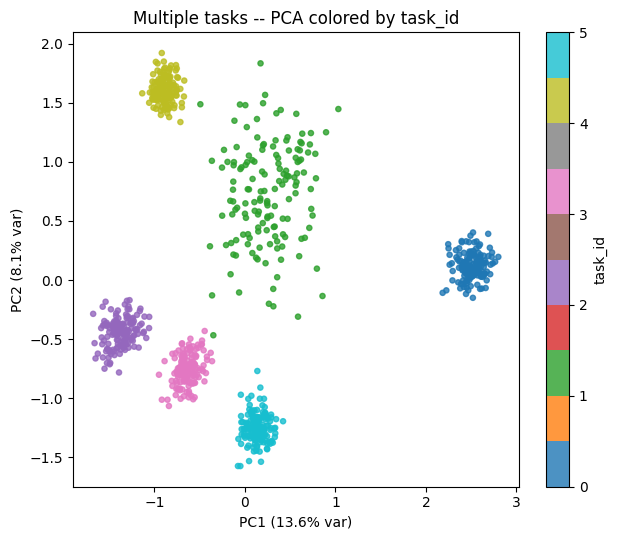

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


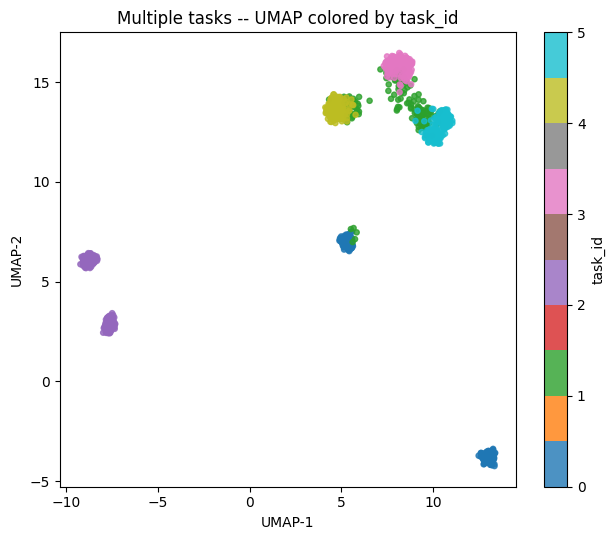

  0: 05269061
  1: 05a7bcf2
  2: 05f2a901
  3: 0607ce86
  4: 0692e18c
  5: 06df4c85


In [13]:

def get_multi_task_embeddings(task_ids, max_rows_per_task: int = 150):
    all_emb, task_labels = [], []
    for tid in task_ids:
        e, _names, _t, _c = get_task_augmentation_embeddings(tid, max_rows=max_rows_per_task)
        all_emb.append(e)
        task_labels.extend([tid] * len(e))
    return np.concatenate(all_emb, axis=0), task_labels


MULTI_TASK_IDS = all_task_ids_v2[10:16]
multi_emb, multi_task_labels = get_multi_task_embeddings(MULTI_TASK_IDS, max_rows_per_task=150)

task_id_to_int = {tid: i for i, tid in enumerate(MULTI_TASK_IDS)}
multi_color = np.array([task_id_to_int[t] for t in multi_task_labels])

print(f"{multi_emb.shape[0]} total rows across {len(MULTI_TASK_IDS)} tasks, dim={multi_emb.shape[1]}")

proj_pca = plot_pca_scatter(multi_emb, multi_color, title="Multiple tasks", label="task_id", cmap="tab10")
proj_umap = plot_umap_scatter(multi_emb, multi_color, title="Multiple tasks", label="task_id", cmap="tab10")

for tid, i in task_id_to_int.items():
    print(f"  {i}: {tid}")


## 10. Model loading (needed to classify tasks by canonical vs. augmented solvability)

Sections 1-9 never needed a runnable model -- everything came straight from the
checkpoint's raw embedding tensor. Classifying which tasks TRM actually *solves*
canonically vs. under augmentation requires real inference, so this section adds
the same patches + `load_model_for_dataset`/`run_single` machinery from the
comparison notebook (verbatim), then loads one model on `v2_baseline_data`.

In [14]:
# --- Patch: fix RuntimeError in Attention.forward (verified bug in models/layers.py) ---
import importlib
import einops as _einops
from torch.nn.functional import scaled_dot_product_attention as _sdpa


def _patch_attention_view_bug() -> None:
    layers_mod = importlib.import_module("models.layers")

    def _patched_forward(self, cos_sin, hidden_states):
        batch_size, seq_len, _ = hidden_states.shape
        qkv = self.qkv_proj(hidden_states)
        qkv = qkv.view(batch_size, seq_len, self.num_heads + 2 * self.num_key_value_heads, self.head_dim)
        query = qkv[:, :, :self.num_heads]
        key = qkv[:, :, self.num_heads: self.num_heads + self.num_key_value_heads]
        value = qkv[:, :, self.num_heads + self.num_key_value_heads:]

        if cos_sin is not None:
            cos, sin = cos_sin
            query, key = layers_mod.apply_rotary_pos_emb(query, key, cos, sin)

        query, key, value = map(lambda t: _einops.rearrange(t, 'B S H D -> B H S D'), (query, key, value))
        attn_output = _sdpa(query=query, key=key, value=value, is_causal=self.causal)
        attn_output = _einops.rearrange(attn_output, 'B H S D -> B S H D')
        attn_output = attn_output.reshape(batch_size, seq_len, self.output_size)  # FIX: .reshape(), not .view()
        return self.o_proj(attn_output)

    layers_mod.Attention.forward = _patched_forward
    print("[patch] models.layers.Attention.forward patched: .view() -> .reshape() after rearrange")


_patch_attention_view_bug()


[patch] models.layers.Attention.forward patched: .view() -> .reshape() after rearrange


In [15]:
os.environ["DISABLE_COMPILE"] = "1"  # avoid a dynamo graph-break in create_model()'s torch.compile()

from hydra import initialize_config_dir, compose
from experiments.run_expC_puzzle_id import (
    _patch_load_checkpoint, _patch_trm_device_alignment, _init_single_process_dist,
)
from pretrain import load_synced_config, create_dataloader, create_model
from dataset.build_arc_dataset import np_grid_to_seq_translational_augment
from evaluators.arc import _crop

_patch_load_checkpoint()
_patch_trm_device_alignment()
_init_single_process_dist()


def load_model_for_dataset(data_dir: str, load_checkpoint):
    overrides = [f"data_paths=[{data_dir}]", f"data_paths_test=[{data_dir}]"]
    if load_checkpoint:
        overrides.append(f"+load_checkpoint={load_checkpoint}")
        ckpt_cfg_path = Path(load_checkpoint).parent / "all_config.yaml"
        if ckpt_cfg_path.exists():
            import yaml
            ckpt_arch = yaml.safe_load(ckpt_cfg_path.read_text()).get("arch", {})
            for key in ("L_cycles", "H_cycles", "L_layers"):
                if ckpt_arch.get(key) is not None:
                    overrides.append(f"arch.{key}={ckpt_arch[key]}")

    with initialize_config_dir(version_base=None, config_dir=f'{CFG["repo_dir"]}/config'):
        hydra_cfg = compose(config_name="cfg_pretrain", overrides=overrides)
    config = load_synced_config(hydra_cfg, rank=0, world_size=1)

    eval_loader, eval_metadata = create_dataloader(
        config, split="test", test_set_mode=True, epochs_per_iter=1,
        global_batch_size=config.global_batch_size, rank=0, world_size=1,
    )
    model, _optimizers, _optimizer_lrs = create_model(config, eval_metadata, rank=0, world_size=1)
    model.eval()
    return model, eval_metadata, config, eval_loader


def grid_to_input_tokens(grid, metadata):
    inp_np = arc_grid_to_np(grid)
    dummy_out = inp_np.copy()
    inp_seq, _ = np_grid_to_seq_translational_augment(inp_np, dummy_out, do_translation=False)
    return torch.tensor(inp_seq, dtype=torch.int32)


def decode_tokens_to_grid(pred_tokens_single):
    pred_np = pred_tokens_single.to(torch.uint8).cpu().numpy()
    cropped = _crop(pred_np)
    if cropped.size == 0 or len(cropped.shape) < 2 or 0 in cropped.shape:
        return [[0]]
    return cropped.tolist()


@torch.inference_mode()
def run_single(model, input_grid, puzzle_id_int, metadata):
    batch = {
        "inputs": grid_to_input_tokens(input_grid, metadata).unsqueeze(0).cuda(),
        "labels": torch.full((1, metadata.seq_len), metadata.ignore_label_id, dtype=torch.int32).cuda(),
        "puzzle_identifiers": torch.tensor([puzzle_id_int], dtype=torch.int32).cuda(),
    }
    carry = model.initial_carry(batch)
    while True:
        carry, _loss, _metrics, preds, all_finish = model(
            carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"}
        )
        if all_finish:
            break
    return decode_tokens_to_grid(preds["preds"][0])


def cell_accuracy(pred_grid, true_grid):
    p = np.array(pred_grid, dtype=np.int64)
    t = np.array(true_grid, dtype=np.int64)
    if p.shape != t.shape:
        h = min(p.shape[0], t.shape[0]); w = min(p.shape[1], t.shape[1])
        if h == 0 or w == 0:
            return 0.0
        return float((p[:h, :w] == t[:h, :w]).mean()) * (h * w) / (t.shape[0] * t.shape[1])
    return float((p == t).mean())


def grid_exact_match(pred_grid, true_grid):
    return int(np.array(pred_grid, dtype=np.int64).tolist() == np.array(true_grid, dtype=np.int64).tolist())


In [16]:
model_v2_baseline, meta_v2_baseline, _, _ = load_model_for_dataset(v2_baseline_data, V2_CKPT_PATH)
assert model_v2_baseline.model.inner.puzzle_emb.weights.shape == ckpt_puzzle_emb_v2.shape, \
    "SHAPE MISMATCH -- still hitting the mean-pool fallback, do not continue past this cell"
print("model_v2_baseline loaded, puzzle_emb shape matches checkpoint:",
      tuple(model_v2_baseline.model.inner.puzzle_emb.weights.shape))


TinyRecursiveReasoningModel_ACTV1(
  (inner): TinyRecursiveReasoningModel_ACTV1_Inner(
    (embed_tokens): CastedEmbedding()
    (lm_head): CastedLinear()
    (q_head): CastedLinear()
    (puzzle_emb): CastedSparseEmbedding()
    (rotary_emb): RotaryEmbedding()
    (L_level): TinyRecursiveReasoningModel_ACTV1ReasoningModule(
      (layers): ModuleList(
        (0-1): 2 x TinyRecursiveReasoningModel_ACTV1Block(
          (self_attn): Attention(
            (qkv_proj): CastedLinear()
            (o_proj): CastedLinear()
          )
          (mlp): SwiGLU(
            (gate_up_proj): CastedLinear()
            (down_proj): CastedLinear()
          )
        )
      )
    )
  )
)
[ExpC] Patched load_checkpoint: checkpoints/hf_trm/arc_v2_public/step_723914
model_v2_baseline loaded, puzzle_emb shape matches checkpoint: (1191730, 512)


## 11. Classify tasks: canonical-solved-only vs. both-solved

For a sample of tasks: score the canonical (un-augmented) test example, and a
handful of real augmented rows, each using that row's own real per-augmentation
embedding (`task_to_id_v2_baseline` for canonical, direct row index for augmented).
`SOLVE_THRESHOLD` controls what counts as "solved" on cell accuracy.

Runtime note: each task costs `1 + N_AUGS_PER_TASK` forward passes through the
full recursive TRM -- keep `N_TASKS_TO_CLASSIFY` modest for a first pass.

In [17]:
import pandas as pd

In [18]:
N_TASKS_TO_CLASSIFY = 5
N_AUGS_PER_TASK = 5
SOLVE_THRESHOLD = 0.95
CLASSIFY_SEED = 0

random.seed(CLASSIFY_SEED)
candidate_pool = [t for t in all_task_ids_v2 if len(tasks_v2[t]["test"]) > 0 and "output" in tasks_v2[t]["test"][0]]
tasks_to_classify = random.sample(candidate_pool, min(N_TASKS_TO_CLASSIFY, len(candidate_pool)))

classification_rows = []
for task_id in tasks_to_classify:
    canon_ex = tasks_v2[task_id]["test"][0]
    canon_id = task_to_id_v2_baseline[task_id]
    canon_pred = run_single(model_v2_baseline, canon_ex["input"], canon_id, meta_v2_baseline)
    canon_acc = cell_accuracy(canon_pred, canon_ex["output"])

    aug_rows = [(i, name) for i, name in enumerate(v2_baseline_ids)
                if name.startswith(task_id + PuzzleIdSeparator)]
    sampled = random.sample(aug_rows, min(N_AUGS_PER_TASK, len(aug_rows)))

    base_ex = tasks_v2[task_id]["train"][0]
    aug_accs = []
    for row_id, row_name in sampled:
        parsed = parse_aug_name(row_name)
        trans_id, mapping = parsed
        aug_inp = dihedral_transform(mapping[np.array(base_ex["input"], dtype=np.uint8)], trans_id).tolist()
        aug_out = dihedral_transform(mapping[np.array(base_ex["output"], dtype=np.uint8)], trans_id).tolist()
        aug_pred = run_single(model_v2_baseline, aug_inp, row_id, meta_v2_baseline)
        aug_accs.append(cell_accuracy(aug_pred, aug_out))

    mean_aug_acc = float(np.mean(aug_accs)) if aug_accs else float("nan")
    classification_rows.append(dict(
        task_id=task_id, canon_acc=canon_acc, mean_aug_acc=mean_aug_acc,
        canon_solved=canon_acc >= SOLVE_THRESHOLD,
        aug_solved=mean_aug_acc >= SOLVE_THRESHOLD,
    ))

classification_df = pd.DataFrame(classification_rows)
canonical_only_task_ids = classification_df.query("canon_solved and not aug_solved")["task_id"].tolist()
both_solved_task_ids = classification_df.query("canon_solved and aug_solved")["task_id"].tolist()

print(f"canonical-solved-only: {len(canonical_only_task_ids)} tasks")
print(f"both-solved: {len(both_solved_task_ids)} tasks")
print(f"(neither/aug-only, excluded from comparison below: "
      f"{len(classification_df) - len(canonical_only_task_ids) - len(both_solved_task_ids)} tasks)")
classification_df.sort_values("canon_acc", ascending=False)


canonical-solved-only: 0 tasks
both-solved: 5 tasks
(neither/aug-only, excluded from comparison below: 0 tasks)


,task_id,canon_acc,mean_aug_acc,canon_solved,aug_solved
1,694f12f3,1.00,0.978000,True,True
3,e7a25a18,1.00,0.994444,True,True
2,c9680e90,1.00,1.000000,True,True
4,72a961c9,1.00,0.974074,True,True
0,de493100,0.95,0.980000,True,True


## 12. Cosine similarity across the embedding dim, by solvability group

For each task in each group: cosine similarity between the canonical row's
embedding and each of its sampled augmented rows' embeddings, and mean pairwise
cosine similarity among the augmented rows themselves. Compared as distributions
between the two groups -- hypothesis: if TRM generalizes to augmentations mainly
by having near-identical embeddings across augmented copies, "both-solved" tasks
should show tighter (higher) cosine similarity than "canonical-only" tasks.

In [19]:
import numpy as np
import torch
import random
from sklearn.metrics.pairwise import cosine_similarity

def calculate_inter_task_top200_avg_cosine(task_id_a: str, task_id_b: str, num_samples: int = 50, num_dims: int = 200):
    """
    Directly extracts 50 augmented samples for two tasks, slices the top 200 embedding dimensions,
    and calculates the average cross-task (inter-task) pairwise cosine similarity.
    """
    # 1. Fetch embeddings for Task A
    emb_a, _, trans_ids_a, _ = get_task_augmentation_embeddings(task_id_a)
    aug_indices_a = np.where(trans_ids_a != -1)[0]
    
    # 2. Fetch embeddings for Task B
    emb_b, _, trans_ids_b, _ = get_task_augmentation_embeddings(task_id_b)
    aug_indices_b = np.where(trans_ids_b != -1)[0]
    
    if len(aug_indices_a) < num_samples or len(aug_indices_b) < num_samples:
        raise ValueError("One or both tasks have fewer than requested augmented samples.")
    
    # 3. Randomly sample 50 augmented rows from each task
    np.random.seed(42)
    sample_a_idx = np.random.choice(aug_indices_a, size=num_samples, replace=False)
    sample_b_idx = np.random.choice(aug_indices_b, size=num_samples, replace=False)
    
    # Slice the first 200 embedding dimensions directly (no SVD projection)
    task_a_50x200 = emb_a[sample_a_idx, :num_dims]  # Shape: (50, 200)
    task_b_50x200 = emb_b[sample_b_idx, :num_dims]  # Shape: (50, 200)
    
    # 4. Compute cross-task pairwise cosine similarity matrix (50 x 50)
    inter_sim_matrix = cosine_similarity(task_a_50x200, task_b_50x200)
    
    # Average across all 2,500 pairwise cross-task comparisons
    avg_cross_cosine = float(np.mean(inter_sim_matrix))
    
    return avg_cross_cosine

# --- Run on two sample tasks from Section 9 ---
task_1 = all_task_ids_v2[10]  # '05269061'
task_2 = all_task_ids_v2[11]  # '05a7bcf2'

avg_inter_cos = calculate_inter_task_top200_avg_cosine(task_1, task_2, num_samples=50, num_dims=200)

print(f"Task A: {task_1} | Task B: {task_2}")
print(f"Average Inter-Task Cosine Similarity (Top 200 Dims, 50 Augs each): {avg_inter_cos:.4f}")

Task A: 05269061 | Task B: 05a7bcf2
Average Inter-Task Cosine Similarity (Top 200 Dims, 50 Augs each): 0.0345


In [20]:
import numpy as np
import torch
import random
from sklearn.metrics.pairwise import cosine_similarity

def calculate_top200_cosine_similarities(task_id_a: str, task_id_b: str, num_samples: int = 50, num_dims: int = 200):
    """
    Directly extracts 50 augmented samples for two tasks, slices the top 200 raw embedding dimensions,
    and computes:
      1. Intra-task avg cosine similarity (augmented vs. augmented within Task A)
      2. Intra-task avg cosine similarity (augmented vs. augmented within Task B)
      3. Inter-task avg cosine similarity (augmented Task A vs. augmented Task B)
    """
    # 1. Fetch embeddings for Task A
    emb_a, _, trans_ids_a, _ = get_task_augmentation_embeddings(task_id_a)
    aug_indices_a = np.where(trans_ids_a != -1)[0]
    
    # 2. Fetch embeddings for Task B
    emb_b, _, trans_ids_b, _ = get_task_augmentation_embeddings(task_id_b)
    aug_indices_b = np.where(trans_ids_b != -1)[0]
    
    if len(aug_indices_a) < num_samples or len(aug_indices_b) < num_samples:
        raise ValueError("One or both tasks have fewer than requested augmented samples.")
    
    # 3. Randomly sample 50 augmented rows from each task
    np.random.seed(42)
    sample_a_idx = np.random.choice(aug_indices_a, size=num_samples, replace=False)
    sample_b_idx = np.random.choice(aug_indices_b, size=num_samples, replace=False)
    
    # Slice the first 200 embedding dimensions directly
    task_a_50x200 = emb_a[sample_a_idx, :num_dims]  # Shape: (50, 200)
    task_b_50x200 = emb_b[sample_b_idx, :num_dims]  # Shape: (50, 200)
    
    # --- A. Intra-task Cosine (Task A) ---
    sim_a = cosine_similarity(task_a_50x200)
    intra_a_avg = float(np.mean(sim_a[np.triu_indices_from(sim_a, k=1)]))
    
    # --- B. Intra-task Cosine (Task B) ---
    sim_b = cosine_similarity(task_b_50x200)
    intra_b_avg = float(np.mean(sim_b[np.triu_indices_from(sim_b, k=1)]))
    
    # --- C. Inter-task Cosine (Task A vs Task B) ---
    inter_sim = cosine_similarity(task_a_50x200, task_b_50x200)
    inter_avg = float(np.mean(inter_sim))
    
    return {
        "intra_task_a": intra_a_avg,
        "intra_task_b": intra_b_avg,
        "inter_task": inter_avg
    }

# --- Run on sample tasks from Section 9 ---
task_1 = all_task_ids_v2[10]  # '05269061'
task_2 = all_task_ids_v2[11]  # '05a7bcf2'

results = calculate_top200_cosine_similarities(task_1, task_2, num_samples=50, num_dims=200)

print(f"Task A: {task_1} | Task B: {task_2}\n" + "-"*45)
print(f"Intra-Task A Avg Cosine ({task_1} augs): {results['intra_task_a']:.4f}")
print(f"Intra-Task B Avg Cosine ({task_2} augs): {results['intra_task_b']:.4f}")
print(f"Inter-Task Avg Cosine (Task A vs B):    {results['inter_task']:.4f}")

Task A: 05269061 | Task B: 05a7bcf2
---------------------------------------------
Intra-Task A Avg Cosine (05269061 augs): 0.6677
Intra-Task B Avg Cosine (05a7bcf2 augs): 0.1818
Inter-Task Avg Cosine (Task A vs B):    0.0345


In [21]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, accuracy_score

def evaluate_gmm_task_clustering(task_ids, n_components=None, random_state=42):
    """
    Fits a Gaussian Mixture Model on all augmentations across the provided tasks
    and evaluates whether augmentations of the same task cluster together.
    """
    if n_components is None:
        n_components = len(task_ids)
        
    print(f"1. Extracting embeddings for {len(task_ids)} tasks...")
    all_emb, true_task_labels = [], []
    
    for tid in task_ids:
        emb, _, _, _ = get_task_augmentation_embeddings(tid)
        all_emb.append(emb)
        true_task_labels.extend([tid] * len(emb))
        
    X = np.concatenate(all_emb, axis=0)
    true_task_labels = np.array(true_task_labels)
    
    print(f"   -> Total shape: {X.shape} ({len(task_ids)} tasks, ~{X.shape[0]//len(task_ids)} augs/task)")
    
    # 2. Fit GMM with regularization & k-means++ init for high-dimensional stability
    print(f"\n2. Fitting GaussianMixture(n_components={n_components}, covariance_type='diag')...")
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='diag',
        reg_covar=1e-3,          # FIX: Prevents singular covariance / numerical collapse in 512D
        init_params='k-means++', # FIX: Speeds up convergence significantly
        random_state=random_state,
        max_iter=100
    )
    pred_clusters = gmm.fit_predict(X)
    
    # 3. Map each numeric GMM cluster (0..k-1) to the most common true task_id in that cluster
    print("\n3. Evaluating cluster alignment...")
    cluster_to_task = {}
    pred_task_labels = np.empty_like(true_task_labels)
    
    for cluster_idx in range(n_components):
        mask = (pred_clusters == cluster_idx)
        if np.any(mask):
            # FIX: Using pandas mode to avoid scipy version incompatibility
            majority_task = pd.Series(true_task_labels[mask]).mode()[0]
            cluster_to_task[cluster_idx] = majority_task
            pred_task_labels[mask] = majority_task
        else:
            cluster_to_task[cluster_idx] = "EMPTY_CLUSTER"
            
    # 4. Global Metrics
    ari = adjusted_rand_score(true_task_labels, pred_clusters)
    acc = accuracy_score(true_task_labels, pred_task_labels)
    
    print(f"\n" + "="*50)
    print(f"GLOBAL CLUSTERING RESULTS (30 Tasks, 512 Dims)")
    print(f"="*50)
    print(f"Adjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect task clustering)")
    print(f"Overall Accuracy          : {acc*100:.2f}%  (Augs in correct task cluster)")
    print(f"="*50)
    
    # 5. Per-Task Breakdown Table
    records = []
    for tid in task_ids:
        task_mask = (true_task_labels == tid)
        total_augs = np.sum(task_mask)
        
        assigned_clusters = pred_clusters[task_mask]
        primary_cluster = int(pd.Series(assigned_clusters).mode()[0])
        primary_count = int(np.sum(assigned_clusters == primary_cluster))
        
        purity_pct = (primary_count / total_augs) * 100
        records.append({
            "Task ID": tid,
            "Total Augs": total_augs,
            "Primary Cluster": primary_cluster,
            "Augs in Primary": primary_count,
            "Task Purity (%)": round(purity_pct, 1)
        })
        
    df_results = pd.DataFrame(records)
    return gmm, df_results, ari, acc

# --- Run across 30 tasks from your loaded dataset ---
selected_30_tasks = all_task_ids_v2[:30]

gmm_model, task_summary_df, ari_score, accuracy = evaluate_gmm_task_clustering(
    task_ids=selected_30_tasks,
    n_components=30
)

# Display the first 15 tasks in the summary table
display(task_summary_df.head(15))

1. Extracting embeddings for 30 tasks...
   -> Total shape: (28042, 512) (30 tasks, ~934 augs/task)

2. Fitting GaussianMixture(n_components=30, covariance_type='diag')...

3. Evaluating cluster alignment...

GLOBAL CLUSTERING RESULTS (30 Tasks, 512 Dims)
Adjusted Rand Index (ARI) : 0.7570  (1.0 = perfect task clustering)
Overall Accuracy          : 84.69%  (Augs in correct task cluster)


,Task ID,Total Augs,Primary Cluster,Augs in Primary,Task Purity (%)
0,00576224,1001,26,501,50.0
1,007bbfb7,1001,6,1001,100.0
2,009d5c81,1001,14,1001,100.0
3,00d62c1b,576,12,576,100.0
4,00dbd492,1001,1,1001,100.0
5,017c7c7b,576,5,576,100.0
6,025d127b,1001,3,1001,100.0
7,03560426,1001,22,1001,100.0
8,045e512c,1001,13,1001,100.0
9,0520fde7,1001,29,1001,100.0


1. Extracting embeddings for 30 tasks...
   -> Total shape: (28042, 512) (30 tasks, ~934 augs/task)

2. Fitting GaussianMixture(n_components=30, covariance_type='diag')...

3. Evaluating cluster alignment...

GLOBAL CLUSTERING RESULTS (30 Tasks, 512 Dims)
Adjusted Rand Index (ARI) : 0.7570  (1.0 = perfect task clustering)
Overall Accuracy          : 84.69%  (Augs in correct task cluster)


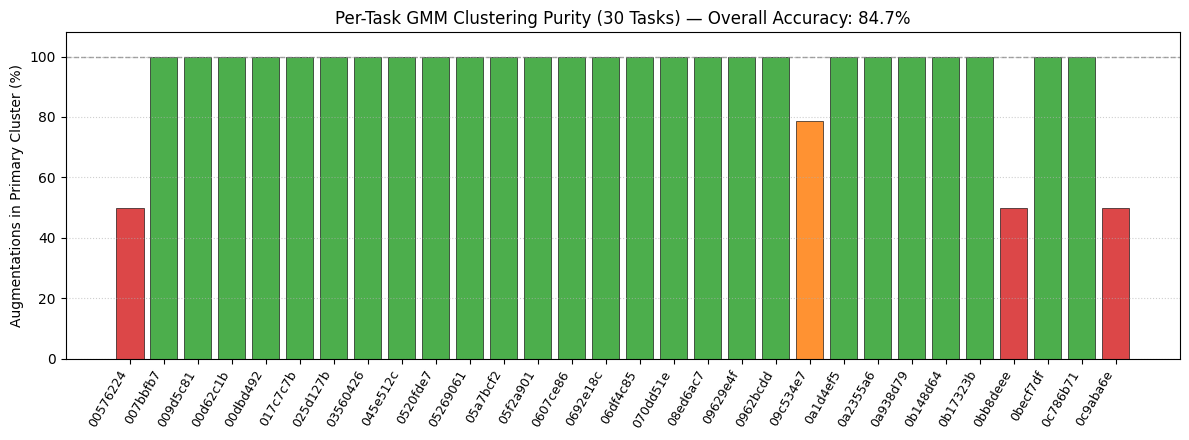

Generating UMAP 2D projection for cluster visual comparison...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


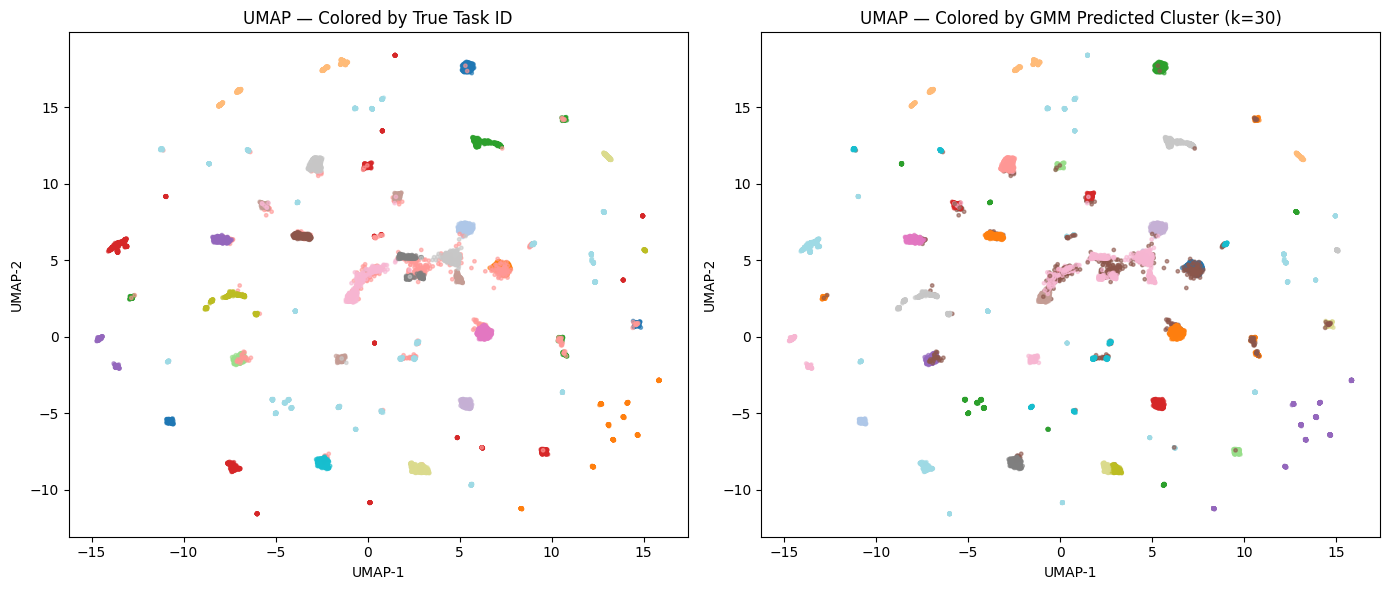

,Task ID,Total Augs,Primary Cluster,Augs in Primary,Task Purity (%)
0,00576224,1001,26,501,50.0
1,007bbfb7,1001,6,1001,100.0
2,009d5c81,1001,14,1001,100.0
3,00d62c1b,576,12,576,100.0
4,00dbd492,1001,1,1001,100.0
5,017c7c7b,576,5,576,100.0
6,025d127b,1001,3,1001,100.0
7,03560426,1001,22,1001,100.0
8,045e512c,1001,13,1001,100.0
9,0520fde7,1001,29,1001,100.0


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, accuracy_score
import umap

def evaluate_gmm_task_clustering(task_ids, n_components=None, random_state=42):
    """
    Fits a Gaussian Mixture Model on all augmentations across the provided tasks,
    evaluates whether augmentations of the same task cluster together, and plots the results.
    """
    if n_components is None:
        n_components = len(task_ids)
        
    print(f"1. Extracting embeddings for {len(task_ids)} tasks...")
    all_emb, true_task_labels = [], []
    
    for tid in task_ids:
        emb, _, _, _ = get_task_augmentation_embeddings(tid)
        all_emb.append(emb)
        true_task_labels.extend([tid] * len(emb))
        
    X = np.concatenate(all_emb, axis=0)
    true_task_labels = np.array(true_task_labels)
    
    print(f"   -> Total shape: {X.shape} ({len(task_ids)} tasks, ~{X.shape[0]//len(task_ids)} augs/task)")
    
    # 2. Fit GMM with regularization & k-means++ init for high-dimensional stability
    print(f"\n2. Fitting GaussianMixture(n_components={n_components}, covariance_type='diag')...")
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='diag',
        reg_covar=1e-3,
        init_params='k-means++',
        random_state=random_state,
        max_iter=100
    )
    pred_clusters = gmm.fit_predict(X)
    
    # 3. Map each numeric GMM cluster (0..k-1) to the most common true task_id in that cluster
    print("\n3. Evaluating cluster alignment...")
    cluster_to_task = {}
    pred_task_labels = np.empty_like(true_task_labels)
    
    for cluster_idx in range(n_components):
        mask = (pred_clusters == cluster_idx)
        if np.any(mask):
            majority_task = pd.Series(true_task_labels[mask]).mode()[0]
            cluster_to_task[cluster_idx] = majority_task
            pred_task_labels[mask] = majority_task
        else:
            cluster_to_task[cluster_idx] = "EMPTY_CLUSTER"
            
    # 4. Global Metrics
    ari = adjusted_rand_score(true_task_labels, pred_clusters)
    acc = accuracy_score(true_task_labels, pred_task_labels)
    
    print(f"\n" + "="*55)
    print(f"GLOBAL CLUSTERING RESULTS (30 Tasks, 512 Dims)")
    print(f"="*55)
    print(f"Adjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect task clustering)")
    print(f"Overall Accuracy          : {acc*100:.2f}%  (Augs in correct task cluster)")
    print(f"="*55)
    
    # 5. Per-Task Breakdown Table
    records = []
    for tid in task_ids:
        task_mask = (true_task_labels == tid)
        total_augs = np.sum(task_mask)
        
        assigned_clusters = pred_clusters[task_mask]
        primary_cluster = int(pd.Series(assigned_clusters).mode()[0])
        primary_count = int(np.sum(assigned_clusters == primary_cluster))
        
        purity_pct = (primary_count / total_augs) * 100
        records.append({
            "Task ID": tid,
            "Total Augs": total_augs,
            "Primary Cluster": primary_cluster,
            "Augs in Primary": primary_count,
            "Task Purity (%)": round(purity_pct, 1)
        })
        
    df_results = pd.DataFrame(records)
    
    # ==========================================
    # 6. PLOTTING
    # ==========================================
    
    # --- PLOT 1: Per-Task Clustering Purity Bar Chart ---
    fig, ax = plt.subplots(figsize=(12, 4.5))
    x_indices = np.arange(len(df_results))
    purities = df_results["Task Purity (%)"]
    
    # Color bars based on purity threshold (Green for >=90%, Orange/Red otherwise)
    colors = ['#2ca02c' if p >= 90 else '#ff7f0e' if p >= 60 else '#d62728' for p in purities]
    
    bars = ax.bar(x_indices, purities, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylim(0, 108)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(df_results["Task ID"], rotation=60, ha='right', fontsize=9)
    ax.set_ylabel("Augmentations in Primary Cluster (%)")
    ax.set_title(f"Per-Task GMM Clustering Purity ({len(task_ids)} Tasks) — Overall Accuracy: {acc*100:.1f}%")
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    # --- PLOT 2: UMAP Projection (True Task ID vs. GMM Cluster) ---
    print("Generating UMAP 2D projection for cluster visual comparison...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    proj = reducer.fit_transform(X)
    
    # Encode true labels to numeric for colormap
    task_id_to_int = {tid: i for i, tid in enumerate(task_ids)}
    true_color_vals = np.array([task_id_to_int[t] for t in true_task_labels])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: True Task IDs
    sc1 = axes[0].scatter(proj[:, 0], proj[:, 1], c=true_color_vals, cmap="tab20", s=6, alpha=0.6)
    axes[0].set_title("UMAP — Colored by True Task ID")
    axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
    
    # Right: GMM Predicted Clusters
    sc2 = axes[1].scatter(proj[:, 0], proj[:, 1], c=pred_clusters, cmap="tab20", s=6, alpha=0.6)
    axes[1].set_title(f"UMAP — Colored by GMM Predicted Cluster (k={n_components})")
    axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
    
    plt.tight_layout()
    plt.show()
    
    return gmm, df_results, ari, acc

# --- Run across 30 tasks from your loaded dataset ---
selected_30_tasks = all_task_ids_v2[:30]

gmm_model, task_summary_df, ari_score, accuracy = evaluate_gmm_task_clustering(
    task_ids=selected_30_tasks,
    n_components=30
)

# Display the first 15 tasks in the summary table
display(task_summary_df.head(15))

TOP 200 DIMENSIONS PAIRWISE COSINE SIMILARITY (50 AUGS)
Intra-Task A (140c817e) Mean Cosine Sim : 0.4252 (±0.0665)
Intra-Task B (1190e5a7) Mean Cosine Sim : 0.5843 (±0.0594)
Inter-Task  (A vs B)   Mean Cosine Sim : 0.1397 (±0.0638)


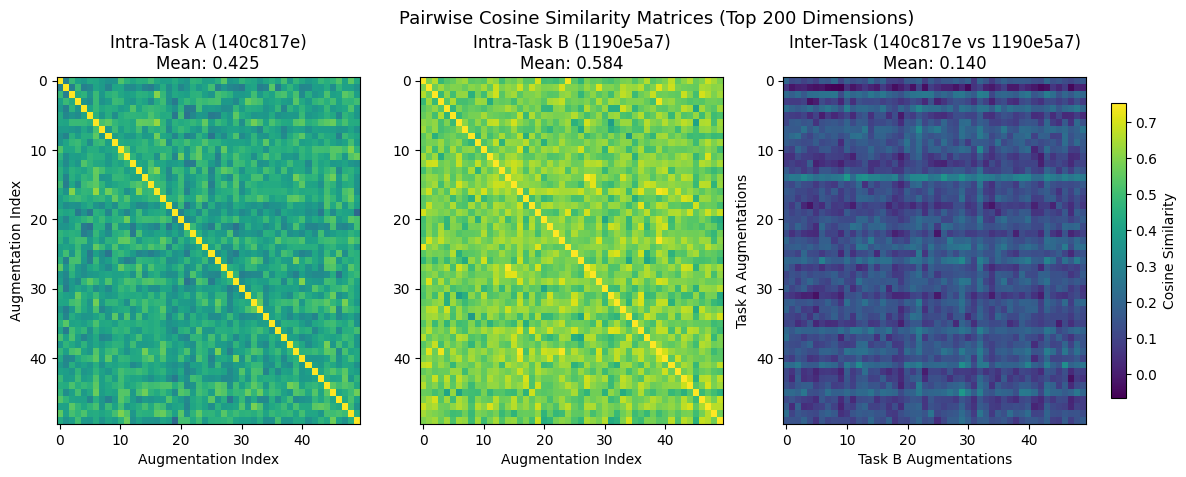

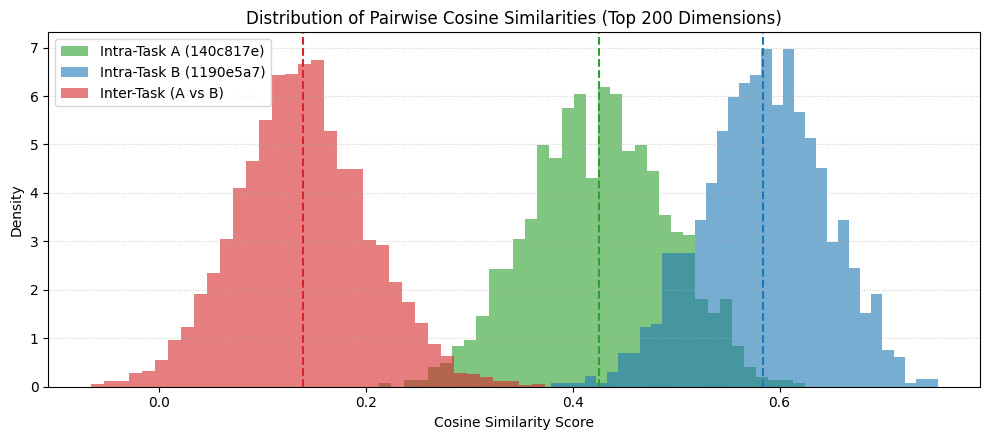

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def plot_inter_vs_intra_cosine_similarity(task_id_a: str, task_id_b: str, num_samples: int = 50, num_dims: int = 200):
    """
    Computes pairwise cosine similarity on the top `num_dims` dimensions for 50 augmentations
    of two tasks, reporting average similarities and plotting both heatmaps and distributions.
    """
    # 1. Fetch embeddings and filter out canonical rows (trans_id == -1)
    emb_a, _, trans_a, _ = get_task_augmentation_embeddings(task_id_a)
    emb_b, _, trans_b, _ = get_task_augmentation_embeddings(task_id_b)
    
    aug_idx_a = np.where(trans_a != -1)[0]
    aug_idx_b = np.where(trans_b != -1)[0]
    
    if len(aug_idx_a) < num_samples or len(aug_idx_b) < num_samples:
        raise ValueError(f"Tasks must have at least {num_samples} augmented rows.")
        
    # 2. Sample 50 random augmented rows and slice top 200 dimensions
    np.random.seed(42)
    sample_a = emb_a[np.random.choice(aug_idx_a, size=num_samples, replace=False), :num_dims]
    sample_b = emb_b[np.random.choice(aug_idx_b, size=num_samples, replace=False), :num_dims]
    
    # 3. Compute 50x50 Pairwise Cosine Similarity Matrices
    sim_intra_a = cosine_similarity(sample_a)
    sim_intra_b = cosine_similarity(sample_b)
    sim_inter   = cosine_similarity(sample_a, sample_b)
    
    # Extract off-diagonal values for intra-task (to exclude self-similarity = 1.0)
    triu_idx = np.triu_indices_from(sim_intra_a, k=1)
    vals_intra_a = sim_intra_a[triu_idx]
    vals_intra_b = sim_intra_b[triu_idx]
    vals_inter   = sim_inter.flatten()  # All 2,500 pairs are valid inter-task comparisons
    
    # 4. Print Numeric Summary
    print("="*60)
    print(f"TOP {num_dims} DIMENSIONS PAIRWISE COSINE SIMILARITY ({num_samples} AUGS)")
    print("="*60)
    print(f"Intra-Task A ({task_id_a}) Mean Cosine Sim : {vals_intra_a.mean():.4f} (±{vals_intra_a.std():.4f})")
    print(f"Intra-Task B ({task_id_b}) Mean Cosine Sim : {vals_intra_b.mean():.4f} (±{vals_intra_b.std():.4f})")
    print(f"Inter-Task  (A vs B)   Mean Cosine Sim : {vals_inter.mean():.4f} (±{vals_inter.std():.4f})")
    print("="*60)
    
    # ==========================================
    # 5. PLOTTING
    # ==========================================
    
    # --- PLOT 1: Side-by-Side Similarity Heatmaps ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    # Shared color limit scale for fair visual comparison across all three matrices
    vmin = min(vals_intra_a.min(), vals_intra_b.min(), vals_inter.min())
    vmax = max(vals_intra_a.max(), vals_intra_b.max(), vals_inter.max())
    
    im0 = axes[0].imshow(sim_intra_a, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    axes[0].set_title(f"Intra-Task A ({task_id_a})\nMean: {vals_intra_a.mean():.3f}")
    axes[0].set_xlabel("Augmentation Index"); axes[0].set_ylabel("Augmentation Index")
    
    im1 = axes[1].imshow(sim_intra_b, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    axes[1].set_title(f"Intra-Task B ({task_id_b})\nMean: {vals_intra_b.mean():.3f}")
    axes[1].set_xlabel("Augmentation Index")
    
    im2 = axes[2].imshow(sim_inter, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    axes[2].set_title(f"Inter-Task ({task_id_a} vs {task_id_b})\nMean: {vals_inter.mean():.3f}")
    axes[2].set_xlabel("Task B Augmentations"); axes[2].set_ylabel("Task A Augmentations")
    
    fig.colorbar(im2, ax=axes.ravel().tolist(), label="Cosine Similarity", shrink=0.85, pad=0.02)
    plt.suptitle(f"Pairwise Cosine Similarity Matrices (Top {num_dims} Dimensions)", fontsize=13, y=1.03)
    plt.show()
    
    # --- PLOT 2: Similarity Distribution Comparison ---
    fig, ax = plt.subplots(figsize=(10, 4.5))
    
    ax.hist(vals_intra_a, bins=35, alpha=0.6, density=True, label=f"Intra-Task A ({task_id_a})", color="#2ca02c")
    ax.hist(vals_intra_b, bins=35, alpha=0.6, density=True, label=f"Intra-Task B ({task_id_b})", color="#1f77b4")
    ax.hist(vals_inter,   bins=35, alpha=0.6, density=True, label=f"Inter-Task (A vs B)",       color="#d62728")
    
    # Add vertical dashed lines for group means
    ax.axvline(vals_intra_a.mean(), color="#2ca02c", linestyle="--", linewidth=1.5)
    ax.axvline(vals_intra_b.mean(), color="#1f77b4", linestyle="--", linewidth=1.5)
    ax.axvline(vals_inter.mean(),   color="#d62728", linestyle="--", linewidth=1.5)
    
    ax.set_title(f"Distribution of Pairwise Cosine Similarities (Top {num_dims} Dimensions)")
    ax.set_xlabel("Cosine Similarity Score")
    ax.set_ylabel("Density")
    ax.legend(frameon=True)
    ax.grid(axis="y", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "sim_intra_a": sim_intra_a,
        "sim_intra_b": sim_intra_b,
        "sim_inter": sim_inter
    }

# --- Run on two sample tasks from your loaded dataset ---
task_1 = all_task_ids_v2[50]  # e.g., '05269061'
task_2 = all_task_ids_v2[40]  # e.g., '05a7bcf2'

    
sim_matrices = plot_inter_vs_intra_cosine_similarity(
    task_id_a=task_1,
    task_id_b=task_2,
    num_samples=50,
    num_dims=200
)

VARIANCE EXPLAINED ANALYSIS (140c817e vs 1190e5a7)
Total Combined Matrix Shape : (100, 512)
Top 200 Dimensions Variance Explained : 100.00%


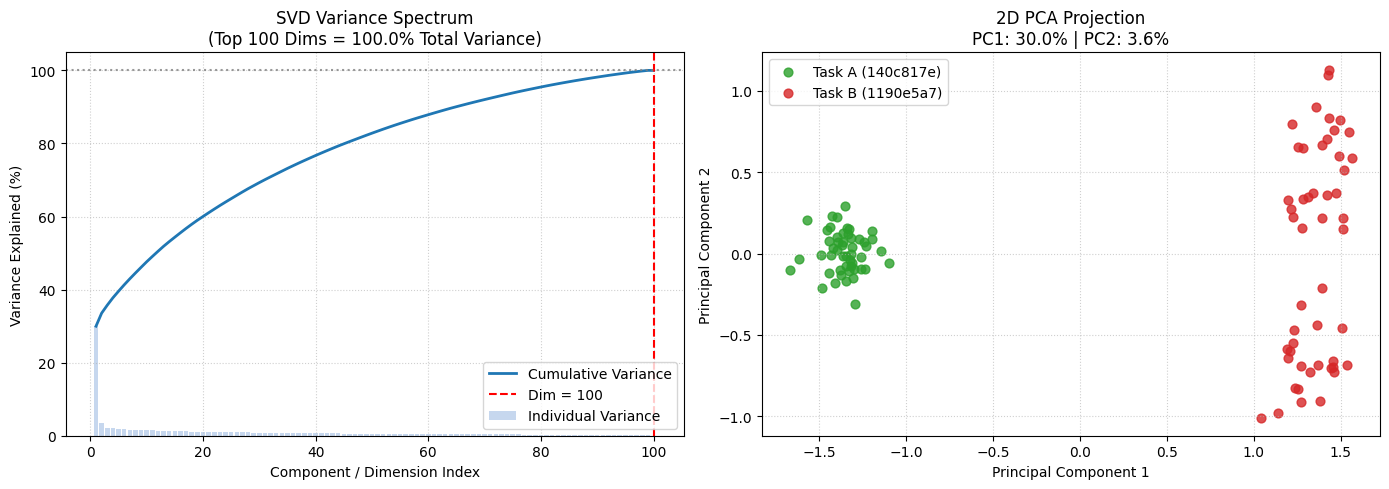

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def analyze_top200_variance_and_plots(task_id_a: str, task_id_b: str, num_samples: int = 50, num_dims: int = 200):
    """
    Calculates the exact variance explained by the top 200 dimensions across 
    50 augmentations of two tasks and plots both variance curves and 2D PCA projection.
    """
    # 1. Fetch embeddings and filter out canonical rows
    emb_a, _, trans_a, _ = get_task_augmentation_embeddings(task_id_a)
    emb_b, _, trans_b, _ = get_task_augmentation_embeddings(task_id_b)
    
    aug_idx_a = np.where(trans_a != -1)[0]
    aug_idx_b = np.where(trans_b != -1)[0]
    
    np.random.seed(42)
    sample_a = emb_a[np.random.choice(aug_idx_a, size=num_samples, replace=False)]
    sample_b = emb_b[np.random.choice(aug_idx_b, size=num_samples, replace=False)]
    
    # Combine samples from both tasks (100 total rows, 512 dimensions)
    X_combined = np.vstack([sample_a, sample_b])
    labels = [f"Task A ({task_id_a})"] * num_samples + [f"Task B ({task_id_b})"] * num_samples
    
    # 2. SVD / Variance Calculation
    centered_X = X_combined - X_combined.mean(axis=0, keepdims=True)
    _U, S, _Vt = np.linalg.svd(centered_X, full_matrices=False)
    
    var_ratio = (S ** 2) / np.sum(S ** 2)
    cum_var = np.cumsum(var_ratio)
    
    exact_var_200 = cum_var[min(num_dims - 1, len(cum_var) - 1)] * 100
    
    print("="*60)
    print(f"VARIANCE EXPLAINED ANALYSIS ({task_id_a} vs {task_id_b})")
    print("="*60)
    print(f"Total Combined Matrix Shape : {X_combined.shape}")
    print(f"Top {num_dims} Dimensions Variance Explained : {exact_var_200:.2f}%")
    print("="*60)
    
    # ==========================================
    # 3. PLOTTING
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Left Plot: Scree & Cumulative Variance ---
    n_components = len(var_ratio)
    axes[0].plot(range(1, n_components + 1), cum_var * 100, color='#1f77b4', linewidth=2, label="Cumulative Variance")
    axes[0].bar(range(1, n_components + 1), var_ratio * 100, color='#aec7e8', alpha=0.7, label="Individual Variance")
    
    # Mark the top 200 cutoff
    target_dim = min(num_dims, n_components)
    axes[0].axvline(target_dim, color='red', linestyle='--', linewidth=1.5, label=f"Dim = {target_dim}")
    axes[0].axhline(exact_var_200, color='gray', linestyle=':', alpha=0.8)
    
    axes[0].set_title(f"SVD Variance Spectrum\n(Top {target_dim} Dims = {exact_var_200:.1f}% Total Variance)")
    axes[0].set_xlabel("Component / Dimension Index")
    axes[0].set_ylabel("Variance Explained (%)")
    axes[0].set_ylim(0, 105)
    axes[0].legend(loc="lower right")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    
    # --- Right Plot: 2D PCA Task Separation ---
    pca = PCA(n_components=2)
    proj_2d = pca.fit_transform(X_combined)
    
    axes[1].scatter(proj_2d[:num_samples, 0], proj_2d[:num_samples, 1], 
                    color='#2ca02c', label=f"Task A ({task_id_a})", s=40, alpha=0.8)
    axes[1].scatter(proj_2d[num_samples:, 0], proj_2d[num_samples:, 1], 
                    color='#d62728', label=f"Task B ({task_id_b})", s=40, alpha=0.8)
    
    axes[1].set_title(f"2D PCA Projection\nPC1: {pca.explained_variance_ratio_[0]*100:.1f}% | PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    axes[1].set_xlabel("Principal Component 1")
    axes[1].set_ylabel("Principal Component 2")
    axes[1].legend(frameon=True)
    axes[1].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    return cum_var, exact_var_200

# --- Run on the same two tasks ---
task_1 = all_task_ids_v2[50]
task_2 = all_task_ids_v2[40]

cum_var, total_var_pct = analyze_top200_variance_and_plots(task_1, task_2, num_samples=50, num_dims=200)

## 13. 3D PCA -- two specific augmentations of the same task

Full augmentation cloud for one task in 3D PCA, with two specific augmented rows
(different dihedral transforms) marked distinctly against the rest of the cloud
and against the canonical row.

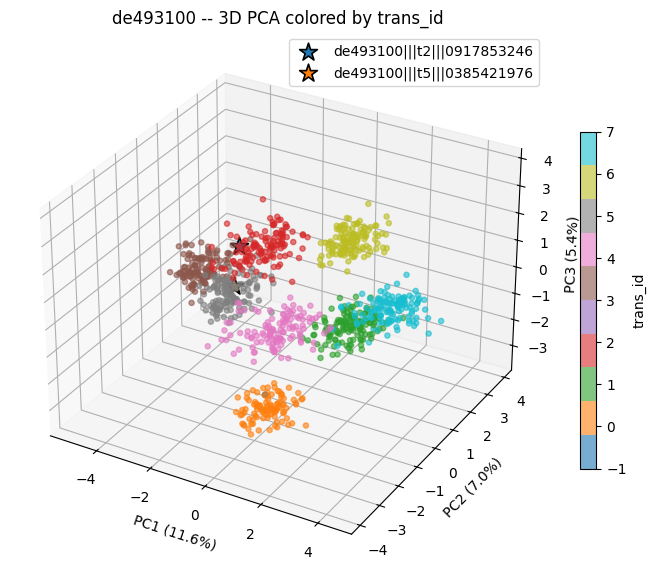

In [25]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

def plot_pca_3d(emb: np.ndarray, color_values, title: str = "", label: str = "",
                 cmap: str = "tab10", highlight_idx=None, highlight_labels=None):
    pca = PCA(n_components=3)
    proj = pca.fit_transform(emb)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(proj[:, 0], proj[:, 1], proj[:, 2], c=color_values, cmap=cmap, s=14, alpha=0.6)

    if highlight_idx is not None:
        for i, hi in enumerate(highlight_idx):
            lbl = highlight_labels[i] if highlight_labels else f"point {hi}"
            ax.scatter(*proj[hi], s=180, marker="*", edgecolor="black", linewidth=1.2, label=lbl)
        ax.legend()

    ax.set_title(f"{title} -- 3D PCA colored by {label}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    plt.colorbar(sc, ax=ax, shrink=0.6, label=label)
    plt.tight_layout()
    plt.show()
    return proj


TWO_AUG_TASK_ID = both_solved_task_ids[0] if both_solved_task_ids else all_task_ids_v2[10]
emb2, names2, trans_ids2, color_perms2 = get_task_augmentation_embeddings(TWO_AUG_TASK_ID)

# pick two augmented rows with genuinely different dihedral transforms
non_canon_idx = np.where(trans_ids2 != -1)[0]
aug_idx_a = int(non_canon_idx[0])
different_transform = trans_ids2[non_canon_idx] != trans_ids2[aug_idx_a]
aug_idx_b = int(non_canon_idx[different_transform][0]) if different_transform.any() else int(non_canon_idx[1])

_ = plot_pca_3d(
    emb2, trans_ids2, title=TWO_AUG_TASK_ID, label="trans_id",
    highlight_idx=[aug_idx_a, aug_idx_b],
    highlight_labels=[f"{names2[aug_idx_a]}", f"{names2[aug_idx_b]}"],
)


## 14. 3D PCA -- different tasks

Same multi-task pooling as Section 9, in 3D instead of 2D.

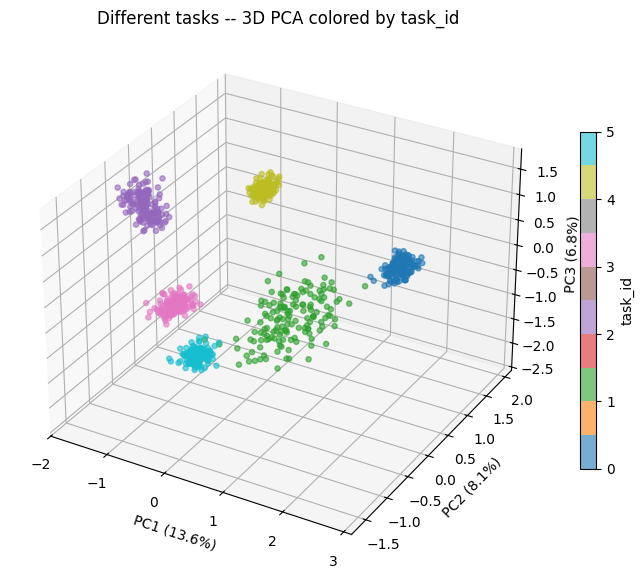

  0: 05269061
  1: 05a7bcf2
  2: 05f2a901
  3: 0607ce86
  4: 0692e18c
  5: 06df4c85


In [26]:
DIFF_TASK_IDS = all_task_ids_v2[10:16]
diff_emb, diff_labels = get_multi_task_embeddings(DIFF_TASK_IDS, max_rows_per_task=150)
diff_task_to_int = {tid: i for i, tid in enumerate(DIFF_TASK_IDS)}
diff_color = np.array([diff_task_to_int[t] for t in diff_labels])

_ = plot_pca_3d(diff_emb, diff_color, title="Different tasks", label="task_id")
for tid, i in diff_task_to_int.items():
    print(f"  {i}: {tid}")


## 15. 3D PCA -- similar tasks vs. fundamentally different tasks

ARC-AGI-2's `concept` subset names tasks like `Count1..Count10`, `ExtractObjects1..10`
-- the numeric suffix strips to a real category label, giving genuine "same family"
groupings instead of an arbitrary guess at task similarity. "Similar" = same
category prefix; "fundamentally different" = tasks pulled from several different
category prefixes.

In [27]:
import re

with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_concept_challenges.json') as f:
    _concept_challenges = _json.load(f)
with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_concept_solutions.json') as f:
    _concept_solutions = _json.load(f)

tasks_v2_concept = copy.deepcopy(_concept_challenges)
for tid, sol in _concept_solutions.items():
    if tid in tasks_v2_concept:
        for i, out in enumerate(sol):
            if i < len(tasks_v2_concept[tid]["test"]):
                tasks_v2_concept[tid]["test"][i]["output"] = out

all_task_ids_v2_concept = list(tasks_v2_concept.keys())
print(f"{len(all_task_ids_v2_concept)} concept tasks loaded.")


def concept_family(task_id: str) -> str:
    m = re.match(r"^([A-Za-z]+)\d+$", task_id)
    return m.group(1) if m else task_id


families = {}
for tid in all_task_ids_v2_concept:
    families.setdefault(concept_family(tid), []).append(tid)
print("Families found:", {k: len(v) for k, v in families.items()})

# only families that actually exist in this checkpoint's embedding table
available_families = {fam: [t for t in ids if t in task_to_id_v2_baseline]
                       for fam, ids in families.items()}
available_families = {fam: ids for fam, ids in available_families.items() if len(ids) >= 3}
print("Usable families (>=3 tasks in the embedding table):", list(available_families.keys())[:10])

SIMILAR_FAMILY = list(available_families.keys())[0]
similar_task_ids = available_families[SIMILAR_FAMILY][:5]

DIFFERENT_FAMILIES = list(available_families.keys())[1:4]
different_task_ids = [ids[0] for fam, ids in available_families.items() if fam in DIFFERENT_FAMILIES]

print("Similar-family tasks:", SIMILAR_FAMILY, similar_task_ids)
print("Fundamentally-different tasks (one per family):", DIFFERENT_FAMILIES, different_task_ids)


160 concept tasks loaded.
Families found: {'ExtractObjects': 10, 'Count': 10, 'Copy': 10, 'Center': 10, 'TopBottom2D7': 1, 'TopBottom2D6': 1, 'TopBottom2D2': 1, 'TopBottom2D3': 1, 'TopBottom2D1': 1, 'TopBottom2D9': 1, 'TopBottom2D5': 1, 'TopBottom2D4': 1, 'TopBottom2D8': 1, 'TopBottom2D10': 1, 'Order': 10, 'MoveToBoundary': 10, 'SameDifferent': 10, 'HorizontalVertical': 10, 'TopBottom3D9': 1, 'TopBottom3D6': 1, 'TopBottom3D1': 1, 'TopBottom3D10': 1, 'TopBottom3D8': 1, 'TopBottom3D5': 1, 'TopBottom3D7': 1, 'TopBottom3D2': 1, 'TopBottom3D4': 1, 'TopBottom3D3': 1, 'CompleteShape': 10, 'AboveBelow': 10, 'FilledNotFilled': 10, 'InsideOutside': 10, 'CleanUp': 10, 'ExtendToBoundary': 10}
Usable families (>=3 tasks in the embedding table): ['ExtractObjects', 'Count', 'Copy', 'Center', 'Order', 'MoveToBoundary', 'SameDifferent', 'HorizontalVertical', 'CompleteShape', 'AboveBelow']
Similar-family tasks: ExtractObjects ['ExtractObjects10', 'ExtractObjects7', 'ExtractObjects9', 'ExtractObjects4', 

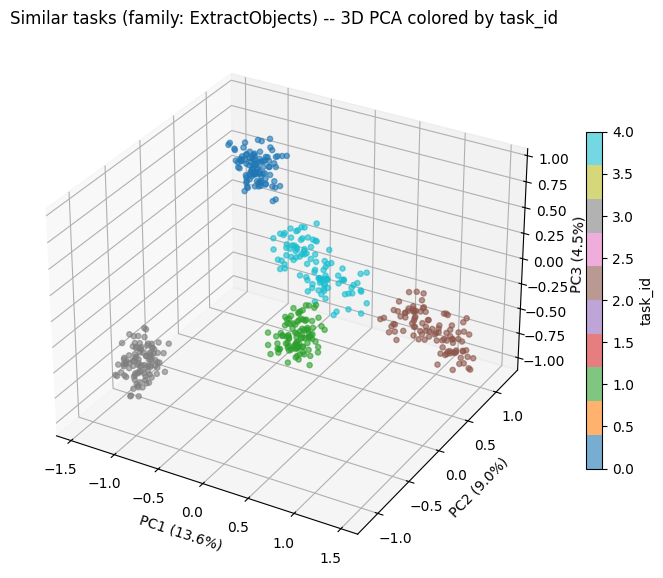

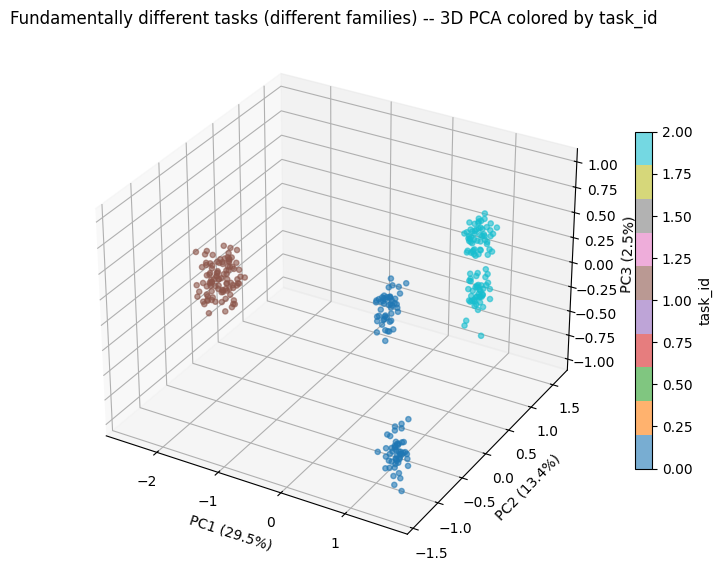

In [28]:
similar_emb, similar_labels = get_multi_task_embeddings(similar_task_ids, max_rows_per_task=100)
similar_task_to_int = {tid: i for i, tid in enumerate(similar_task_ids)}
similar_color = np.array([similar_task_to_int[t] for t in similar_labels])
_ = plot_pca_3d(similar_emb, similar_color, title=f"Similar tasks (family: {SIMILAR_FAMILY})", label="task_id")

diff_fam_emb, diff_fam_labels = get_multi_task_embeddings(different_task_ids, max_rows_per_task=100)
diff_fam_task_to_int = {tid: i for i, tid in enumerate(different_task_ids)}
diff_fam_color = np.array([diff_fam_task_to_int[t] for t in diff_fam_labels])
_ = plot_pca_3d(diff_fam_emb, diff_fam_color, title="Fundamentally different tasks (different families)", label="task_id")


## 16. Additional diagnostics

- **Silhouette score**: quantifies what Sections 9/14/15 show visually -- how
  well task identity (the color label) separates points in embedding space vs.
  how spread out each task's own augmentation cloud is. Higher = tasks separate
  more cleanly from each other relative to their own internal spread.
- **Embedding norm by solvability group**: whether canonical-only vs both-solved
  tasks systematically differ in raw embedding magnitude (a simpler signal than
  cosine direction, worth checking before ruling it out).
- **Nearest-neighbor sanity check**: for each concept-family task, is its nearest
  neighbor (by cosine similarity of the mean embedding across its augmentations)
  actually from the same family? Validates that embedding-space distance tracks
  real task similarity, rather than the clustering in Section 15 being incidental.

In [29]:
from sklearn.metrics import silhouette_score

sil_emb, sil_labels = get_multi_task_embeddings(all_task_ids_v2[10:20], max_rows_per_task=100)
sil_task_to_int = {tid: i for i, tid in enumerate(sorted(set(sil_labels)))}
sil_color = np.array([sil_task_to_int[t] for t in sil_labels])
score = silhouette_score(sil_emb, sil_color, metric="cosine")
print(f"Silhouette score (10 tasks, cosine metric): {score:.3f}  "
      f"(range -1..1; higher = tasks separate more cleanly than their own augmentation spread)")


Silhouette score (10 tasks, cosine metric): 0.325  (range -1..1; higher = tasks separate more cleanly than their own augmentation spread)


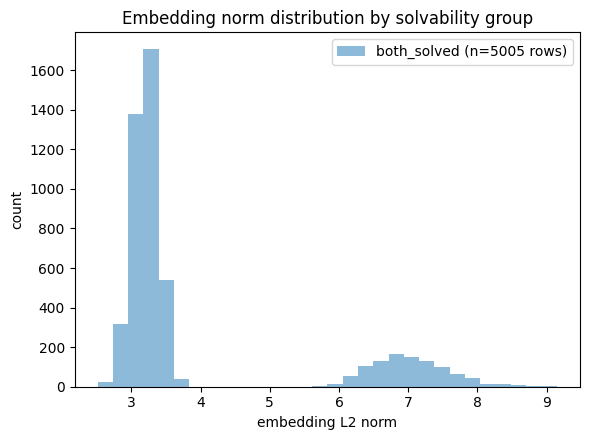

In [30]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for grp_name, ids, color in [("canonical_only", canonical_only_task_ids, "tab:red"),
                              ("both_solved", both_solved_task_ids, "tab:blue")]:
    norms = []
    for tid in ids:
        e, _n, _t, _c = get_task_augmentation_embeddings(tid)
        norms.extend(np.linalg.norm(e, axis=1).tolist())
    if norms:
        ax.hist(norms, bins=30, alpha=0.5, label=f"{grp_name} (n={len(norms)} rows)", color=color)
ax.set_xlabel("embedding L2 norm"); ax.set_ylabel("count")
ax.set_title("Embedding norm distribution by solvability group")
ax.legend()
plt.tight_layout()
plt.show()
